In [1]:
import os
from typing import Optional, List, Any
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from Utils import Notebook, tex, gph, sgn, nm, ds
from pathlib import Path

sns.set_style("whitegrid")

Notebook.setup()

LaTeX has been enabled for text rendering.


In [2]:
# import pandas as pd

# data_file_path: str = 'etc-traffic-logs/single_matrix/kmax30_tmp.csv'


# def remover_linhas_por_valor(arquivo_entrada, arquivo_saida, coluna, valor_para_remover):
#   """
#   Remove linhas de um arquivo CSV onde a coluna especificada possui o valor exato.
#   """
#   df = pd.read_csv(arquivo_entrada)
#   if coluna not in df.columns:
#     raise ValueError(f"A coluna '{coluna}' não foi encontrada no arquivo.")
#   df_filtrado = df[df[coluna] != valor_para_remover]

#   df_filtrado.to_csv(arquivo_saida, index=False)
#   print(f"Arquivo salvo com sucesso em: {arquivo_saida}")


# remover_linhas_por_valor(
#     data_file_path, 'dados_filtrados.csv', 'sigma', 0.0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from typing import Any


def plot_traffic_savings(
    df: pd.DataFrame,
    x_col: str,
    fixed_col: str,
    fixed_val: Any,
    x_label: str,
    log_x: bool = False,
) -> None:
  """
  Plots traffic savings against a specified variable.

  Filters the DataFrame based on a fixed column value and plots the 'SavingsPct'
  against the specified 'x_col'. Handles linear and logarithmic x-axis scales
  and automatically adjusts x-axis tick density using MaxNLocator to prevent 
  label overlap without modifying the base figure or font constraints.

  Args:
      df (pd.DataFrame): The input data containing traffic savings metrics.
      x_col (str): The column name to be plotted on the x-axis.
      fixed_col (str): The column name used to filter the DataFrame.
      fixed_val (Any): The specific value in 'fixed_col' to filter by.
      x_label (str): The label for the x-axis.
      log_x (bool, optional): Whether to use a logarithmic scale for the x-axis. Defaults to False.

  Raises:
      ValueError: If the filtered DataFrame is empty.
  """
  if pd.api.types.is_float_dtype(df[fixed_col]) and isinstance(fixed_val, (float, int)):
    mask = np.isclose(df[fixed_col], fixed_val, rtol=1e-05, atol=1e-08)
  else:
    mask = df[fixed_col] == fixed_val

  df_filtered = df[mask].sort_values(by=x_col)

  if df_filtered.empty:
    raise ValueError(f"No data found for {fixed_col} == {fixed_val}")

  fig, ax = plt.subplots(figsize=(8, 4))

  x_vals = df_filtered[x_col]
  savings = df_filtered['SavingsPct']

  ax.plot(x_vals, savings, marker='o', color='black',
          linestyle='-', linewidth=2, label='Savings')

  ax.set_xlabel(x_label + r' $[\times 10^{-3}]$', fontsize=16)
  ax.set_ylabel(r'Economia mínima [\%]', color='black', fontsize=16)
  ax.tick_params(axis='both', labelsize=16)

  if log_x:
    ax.set_xscale('log')
    min_log = np.log10(np.min(x_vals)) - 0.09
    max_log = np.log10(np.max(x_vals)) + 0.09
    ax.set_xlim(10 ** min_log, 10 ** max_log)
  else:
    min_xlim = np.min(x_vals) - 2
    max_xlim = np.max(x_vals) + 2
    ax.set_xlim(min_xlim, max_xlim)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

    if pd.api.types.is_float_dtype(x_vals):
      ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
      ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))

  ax.set_title(rf'Economia mínima vs. {x_label}', fontsize=14)
  ax.grid(True, linestyle='--', alpha=0.87)

  plt.tight_layout()
  plt.show()

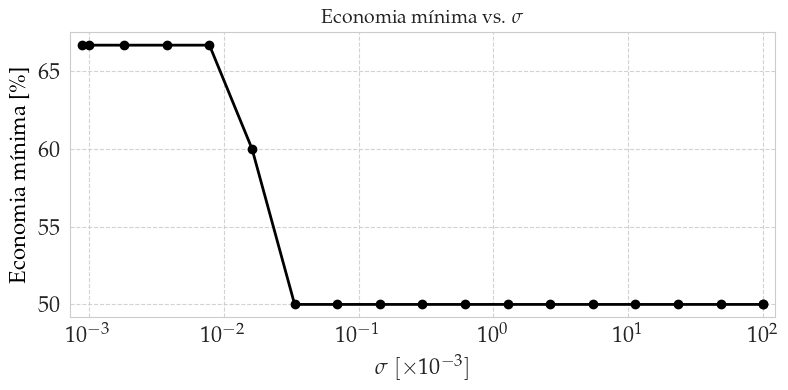

In [4]:
%matplotlib inline

log_file: str = 'etc-traffic-logs/double_matrix/kmax15_tmp.csv'
data = pd.read_csv(log_file)
plot_traffic_savings(data, x_col='eps_tr', x_label=r'$\sigma$',
                     fixed_col='l_word', fixed_val=2, log_x=True)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from typing import Any, List


def plot_limit_bounds(
    df: pd.DataFrame,
    x_col: str,
    fixed_col: str,
    fixed_val: Any,
    x_label: str,
    log_x: bool = False,
) -> None:
  """
  Plots system limit bounds against a specified variable.

  Filters the DataFrame based on a fixed column value and plots multiple 
  boundary variables against the specified 'x_col'. Adapts the x-axis tick 
  density dynamically using MaxNLocator to prevent overlapping labels.

  Args:
      df (pd.DataFrame): The input data containing the boundary metrics.
      x_col (str): The column name to be plotted on the x-axis.
      fixed_col (str): The column name used to filter the DataFrame.
      fixed_val (Any): The specific value in 'fixed_col' to filter by.
      x_label (str): The label for the x-axis.
      log_x (bool, optional): Whether to use a logarithmic scale for the x-axis. Defaults to False.

  Raises:
      ValueError: If the filtered DataFrame is empty.
  """
  if pd.api.types.is_float_dtype(df[fixed_col]) and isinstance(fixed_val, (float, int)):
    mask = np.isclose(df[fixed_col], fixed_val, rtol=1e-05, atol=1e-08)
  else:
    mask = df[fixed_col] == fixed_val

  df_filtered = df[mask].sort_values(by=x_col)

  if df_filtered.empty:
    raise ValueError(f"No data found for {fixed_col} == {fixed_val}")

  fig, ax = plt.subplots(figsize=(8, 4))

  x_vals = df_filtered[x_col] * 1e2
  # x_vals = df_filtered[x_col]
  variables: List[str] = [
      'Inf', 'Sup', 'InfLimInf', 'SupLimSup', 'InfLimAvg', 'SupLimAvg'
  ]
  labels: List[str] = [
      'Inf', 'Sup', 'ILI', 'SLS', 'ILM', 'SLM'
  ]
  markers: List[str] = ['o', 's', '^', 'v', 'D', 'p']
  colors: tuple = ('black', 'brown', 'darkorange', 'darkgoldenrod', 'olivedrab', 'darkgreen',
                   'cadetblue')

  for idx, (var, marker) in enumerate(zip(variables, markers)):
    ax.plot(x_vals, df_filtered[var], marker=marker, color=colors[idx % len(colors)],
            linestyle='-', linewidth=1.5, label=labels[idx])

  ax.set_title(rf'System Limit Bounds vs. {x_label}', fontsize=14)

  # ax.set_xlabel(x_label, fontsize=16)
  ax.set_xlabel(x_label + r" $[\times 10^{-2}]$", fontsize=16)
  ax.set_ylabel('Valores', fontsize=16)
  ax.tick_params(axis='both', labelsize=16)

  min_xlim = np.min(x_vals) - .5
  max_xlim = np.max(x_vals) + .5
  ax.set_xlim(min_xlim, max_xlim)

  ax.set_ylim(0.04, 0.3)

  if log_x:
    ax.set_xscale('log')
  else:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15, integer=False))
    if pd.api.types.is_float_dtype(x_vals):
      ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
      ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))

  ax.legend(loc='best', prop={'size': 13}, ncol=6)
  ax.grid(True, linestyle='--', alpha=0.87)

  plt.tight_layout()
  plt.show()

In [6]:
%matplotlib qt

log_file: str = 'etc-traffic-logs/escalar/kmax10_tmp.csv'
data = pd.read_csv(log_file)
plot_limit_bounds(data, x_col='sigma', x_label=r'$\sigma$',
                  fixed_col='l_word', fixed_val=7, log_x=False)

In [7]:
def plot_entropy(
    df: pd.DataFrame,
    x_col: str,
    fixed_col: str,
    fixed_val: Any,
    x_label: str,
    log_x: bool = False
) -> None:
  df_filtered = df[df[fixed_col] == fixed_val].sort_values(by=x_col)

  if df_filtered.empty:
    raise ValueError(f"No data found for {fixed_col} == {fixed_val}")

  fig, ax = plt.subplots(figsize=(8, 4))

  x_vals = df_filtered[x_col]
  entropy = df_filtered['Entropy']

  ax.plot(x_vals, entropy, marker='s', color='black',
          linestyle='--', linewidth=2, label=fr'$\bar \nu \ge 5$')

  ax.set_xlabel(x_label, fontsize=16)
  ax.set_ylabel(
      r'$\mathcal{H}_b(\mathcal{T}_{\ell})$ [bits]', color='black', fontsize=16)
  ax.tick_params(axis='both', labelsize=16)

  if log_x:
    ax.set_xscale('log')
  else:
    ax.set_xticks(x_vals)
    if pd.api.types.is_float_dtype(x_vals):
      ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    else:
      ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))

  ax.set_xlim(min(x_vals) - 0.25, max(x_vals) + 0.25)

  ax.set_title(rf'Behavioral Entropy vs. {x_label}', fontsize=14)
  ax.legend(loc='best', framealpha=0.95, ncol=4, fontsize=13)
  ax.grid(True, linestyle='--', alpha=0.87)

  plt.tight_layout()

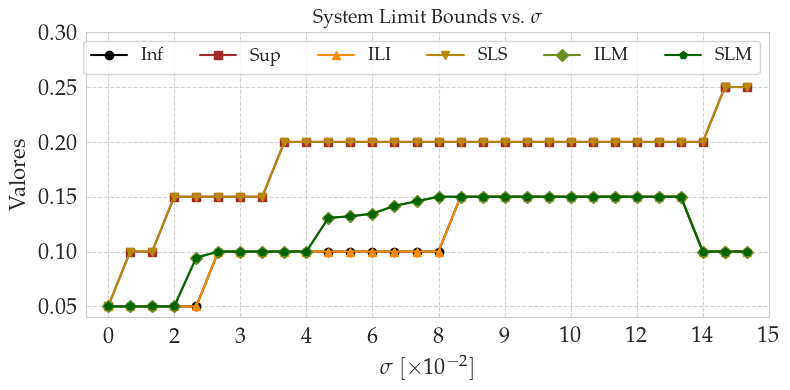

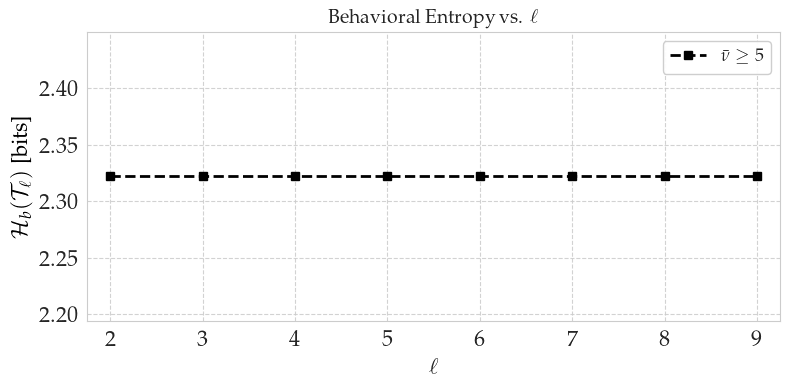

In [8]:
%matplotlib inline

log_file: str = 'etc-traffic-logs/escalar/kmax15_tmp.csv'
data = pd.read_csv(log_file)
plot_entropy(data, x_col='l_word', x_label=r'$\ell$',
             fixed_col='sigma', fixed_val=14e-2)

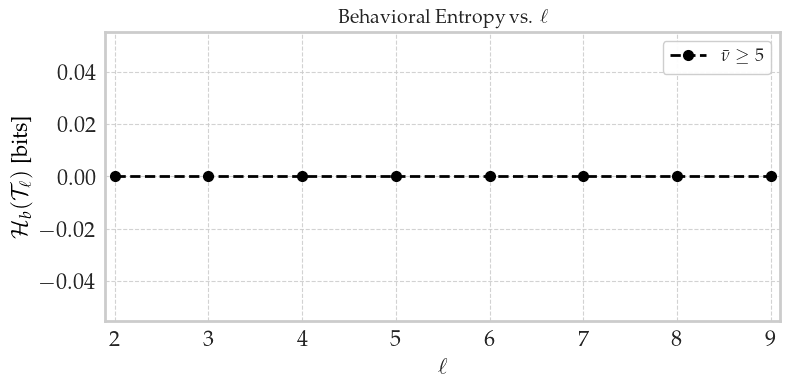

In [9]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from cycler import cycler


def plot_behavioral_entropy_v2(
    kmax_start: int,
    kmax_end: int,
    base_dir: str = 'etc-traffic-logs/double_matrix'
) -> None:
  """
  Plots behavioral entropy vs. word length for different kmax values.

  Applies data sanitization to the independent variable to avoid mixed-type 
  conversions (str/int) that trigger matplotlib categorical type errors 
  during axis tick generation.

  Args:
      kmax_start (int): Starting value for the kmax range.
      kmax_end (int): Ending value for the kmax range.
      base_dir (str, optional): Base directory containing the CSV logs.
                                Defaults to 'etc-traffic-logs/double_matrix'.
  """
  fixed_col: str = 'sigma'
  fixed_val: float = 1e-6
  x_col: str = 'l_word'
  x_label: str = r'$\ell$'
  log_x: bool = False

  fig, ax = plt.subplots(figsize=(8, 4))
  markers: tuple = ('o', 's', '^', 'D', 'v', 'p', '*', 'h')
  colors: tuple = ('black', 'brown', 'darkorange', 'darkgoldenrod', 'olivedrab', 'darkgreen',
                   'cadetblue')

  all_x_vals_list: list = []

  for idx, kmax in enumerate(range(kmax_start, kmax_end + 1)):
    log_file = Path(base_dir) / f'kmax{kmax}_tmp.csv'

    if not log_file.is_file():
      continue

    df = pd.read_csv(log_file)
    df_filtered = df[df[fixed_col] == fixed_val].copy()

    if df_filtered.empty:
      raise ValueError(
          f"Constraint {fixed_col} == {fixed_val} yielded empty DataFrame in {log_file.name}"
      )

    df_filtered[x_col] = pd.to_numeric(df_filtered[x_col], errors='coerce')
    df_filtered = df_filtered.dropna(
        subset=[x_col, 'Entropy']).sort_values(by=x_col)

    x_vals = df_filtered[x_col]
    entropy = df_filtered['Entropy']

    all_x_vals_list.append(x_vals)
    label_str = fr'$\bar \nu={kmax}$' if kmax != kmax_end else fr'$\bar \nu \ge {kmax}$'

    ax.plot(
        x_vals,
        entropy,
        marker=markers[idx % len(markers)],
        markersize=7,
        linestyle='--',
        linewidth=2,
        label=label_str,
        color=colors[idx % len(colors)]
    )

  if not all_x_vals_list:
    print("No valid data available to plot after filtering.")
    return

  ax.set_xlabel(x_label, fontsize=16)
  ax.set_ylabel(
      r'$\mathcal{H}_b(\mathcal{T}_{\ell})$ [bits]', color='black', fontsize=16)
  ax.tick_params(axis='both', labelsize=16)

  all_x_vals_concat = pd.concat(all_x_vals_list)
  all_x_vals_unique = all_x_vals_concat.unique()

  if log_x:
    ax.set_xscale('log')
  else:
    ax.set_xticks(all_x_vals_unique)
    if pd.api.types.is_float_dtype(pd.Series(all_x_vals_unique)):
      ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    else:
      ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))

  ax.set_title(rf'Behavioral Entropy vs. {x_label}', fontsize=14)
  ax.grid(True, linestyle='--', alpha=0.87)
  ax.legend(loc='best', framealpha=0.95, ncol=4, fontsize=13)

  x_min_global = all_x_vals_concat.min()
  x_max_global = all_x_vals_concat.max()
  ax.set_xlim(x_min_global - 0.1, x_max_global + 0.1)

  for spine in ax.spines.values():
    spine.set_linewidth(2)

  plt.tight_layout()

plot_behavioral_entropy_v2(5, 5, base_dir='etc-traffic-logs/escalar')